**Objective:**

The goal of this project is to build a machine learning model that can classify sonar signals to distinguish between rocks and metal cylinders (mines) based on frequency responses.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, roc_curve

dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Machine Learning/Datasets/UCI_Sonar_Dataset.csv', header = None)
dataset.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.036001,0.018991,0.015828,0.061831,0.091641,0.061453,0.096639,0.096555,0.172024,0.202207,...,0.006571,0.017710,0.020391,0.015693,0.010744,0.010397,0.008481,0.009784,0.005001,R
1,0.010467,0.001375,0.000000,0.000000,0.000000,0.035272,0.133258,0.182611,0.243905,0.307986,...,0.000000,0.000000,0.004677,0.006382,0.009028,0.006642,0.005931,0.000078,0.003062,M
2,0.031195,0.029851,0.015650,0.040368,0.064748,0.088087,0.119909,0.118584,0.132309,0.130649,...,0.009625,0.016117,0.010236,0.008164,0.011349,0.007432,0.008796,0.008608,0.009208,R
3,0.054236,0.086304,0.081407,0.092921,0.091274,0.097645,0.122464,0.182208,0.298539,0.301516,...,0.012304,0.006648,0.012478,0.008327,0.006552,0.004455,0.001682,0.004501,0.002634,M
4,0.026964,0.038721,0.051162,0.073747,0.100574,0.157899,0.143043,0.159353,0.164889,0.175796,...,0.019562,0.009628,0.006016,0.007638,0.004513,0.008703,0.011612,0.011428,0.008633,R


In [ ]:
sonar_data = dataset.copy()
feature_names = [
    f'Sonar_Frequency_{i:02d}'
    for i in range(1,61)
]
sonar_data.columns = feature_names + ['Target']

sonar_data.head()

,Sonar_Frequency_01,Sonar_Frequency_02,Sonar_Frequency_03,Sonar_Frequency_04,Sonar_Frequency_05,Sonar_Frequency_06,Sonar_Frequency_07,Sonar_Frequency_08,Sonar_Frequency_09,Sonar_Frequency_10,...,Sonar_Frequency_52,Sonar_Frequency_53,Sonar_Frequency_54,Sonar_Frequency_55,Sonar_Frequency_56,Sonar_Frequency_57,Sonar_Frequency_58,Sonar_Frequency_59,Sonar_Frequency_60,Target
0,0.036001,0.018991,0.015828,0.061831,0.091641,0.061453,0.096639,0.096555,0.172024,0.202207,...,0.006571,0.017710,0.020391,0.015693,0.010744,0.010397,0.008481,0.009784,0.005001,R
1,0.010467,0.001375,0.000000,0.000000,0.000000,0.035272,0.133258,0.182611,0.243905,0.307986,...,0.000000,0.000000,0.004677,0.006382,0.009028,0.006642,0.005931,0.000078,0.003062,M
2,0.031195,0.029851,0.015650,0.040368,0.064748,0.088087,0.119909,0.118584,0.132309,0.130649,...,0.009625,0.016117,0.010236,0.008164,0.011349,0.007432,0.008796,0.008608,0.009208,R
3,0.054236,0.086304,0.081407,0.092921,0.091274,0.097645,0.122464,0.182208,0.298539,0.301516,...,0.012304,0.006648,0.012478,0.008327,0.006552,0.004455,0.001682,0.004501,0.002634,M
4,0.026964,0.038721,0.051162,0.073747,0.100574,0.157899,0.143043,0.159353,0.164889,0.175796,...,0.019562,0.009628,0.006016,0.007638,0.004513,0.008703,0.011612,0.011428,0.008633,R


In [ ]:
print("Shape:",sonar_data.shape)

Shape: (3000, 61)


In [ ]:
sonar_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 61 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Sonar_Frequency_01  2990 non-null   float64
 1   Sonar_Frequency_02  2994 non-null   float64
 2   Sonar_Frequency_03  2991 non-null   float64
 3   Sonar_Frequency_04  2992 non-null   float64
 4   Sonar_Frequency_05  2992 non-null   float64
 5   Sonar_Frequency_06  2991 non-null   float64
 6   Sonar_Frequency_07  2994 non-null   float64
 7   Sonar_Frequency_08  2994 non-null   float64
 8   Sonar_Frequency_09  2992 non-null   float64
 9   Sonar_Frequency_10  2993 non-null   float64
 10  Sonar_Frequency_11  2993 non-null   float64
 11  Sonar_Frequency_12  2991 non-null   float64
 12  Sonar_Frequency_13  2992 non-null   float64
 13  Sonar_Frequency_14  2993 non-null   float64
 14  Sonar_Frequency_15  2994 non-null   float64
 15  Sonar_Frequency_16  2991 non-null   float64
 16  Sonar_

In [ ]:
sonar_data.describe()

,Sonar_Frequency_01,Sonar_Frequency_02,Sonar_Frequency_03,Sonar_Frequency_04,Sonar_Frequency_05,Sonar_Frequency_06,Sonar_Frequency_07,Sonar_Frequency_08,Sonar_Frequency_09,Sonar_Frequency_10,...,Sonar_Frequency_51,Sonar_Frequency_52,Sonar_Frequency_53,Sonar_Frequency_54,Sonar_Frequency_55,Sonar_Frequency_56,Sonar_Frequency_57,Sonar_Frequency_58,Sonar_Frequency_59,Sonar_Frequency_60
count,2990.000000,2994.000000,2991.000000,2992.000000,2992.000000,2991.000000,2994.000000,2994.000000,2992.000000,2993.000000,...,2996.000000,2995.000000,2995.000000,2993.000000,2991.000000,2989.000000,2995.000000,2992.000000,2992.000000,2996.000000
mean,0.030223,0.039639,0.045612,0.055535,0.075881,0.104677,0.121290,0.135796,0.176961,0.206133,...,0.016378,0.013866,0.011050,0.010941,0.009336,0.008059,0.007780,0.007784,0.008028,0.006662
std,0.018869,0.025801,0.030049,0.035620,0.043849,0.047400,0.050314,0.067874,0.099087,0.112796,...,0.010009,0.008047,0.005930,0.006020,0.005670,0.004452,0.004437,0.004968,0.004781,0.003959
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.016788,0.020674,0.022822,0.029098,0.043820,0.072621,0.087266,0.089531,0.105119,0.123641,...,0.009099,0.008119,0.006931,0.006738,0.005174,0.004733,0.004636,0.004260,0.004637,0.003842
50%,0.028087,0.036920,0.042548,0.052420,0.073544,0.102920,0.121112,0.134775,0.170489,0.199658,...,0.015030,0.012968,0.010848,0.010640,0.009067,0.007982,0.007745,0.007350,0.007799,0.006429
75%,0.041441,0.055387,0.064758,0.078504,0.105088,0.136699,0.155572,0.180826,0.241723,0.279354,...,0.022502,0.018849,0.014831,0.014588,0.012968,0.011061,0.010795,0.010933,0.010893,0.009129
max,0.117449,0.155125,0.171502,0.188097,0.238220,0.269322,0.318866,0.387755,0.560627,0.636330,...,0.059975,0.047986,0.033146,0.036188,0.034172,0.024452,0.025949,0.028348,0.027011,0.022637


In [ ]:
# Checking missing values

missing_values = sonar_data.isnull().sum()
print('Total null value:',missing_values.sum())

print("\nColumns with missing values:")
missing_values[missing_values>0].sort_values(ascending=False)

Total null value: 486

Columns with missing values:


,0
Sonar_Frequency_25,17
Sonar_Frequency_35,17
Sonar_Frequency_31,14
Sonar_Frequency_22,14
Sonar_Frequency_27,13
Sonar_Frequency_33,12
Sonar_Frequency_38,11
Sonar_Frequency_56,11
Sonar_Frequency_50,11
Sonar_Frequency_24,10


In [ ]:
# Checking missing values in Target Column
print('Total null values in Target Column:',sonar_data['Target'].isnull().sum())

Total null values in Target Column: 0


In [ ]:
print('Total duplicate values:',sonar_data.duplicated().sum())

Total duplicate values: 0


In [ ]:
# Check value counts of Target Columns
sonar_data['Target'].value_counts()

,count
Target,
M,1637
R,1363


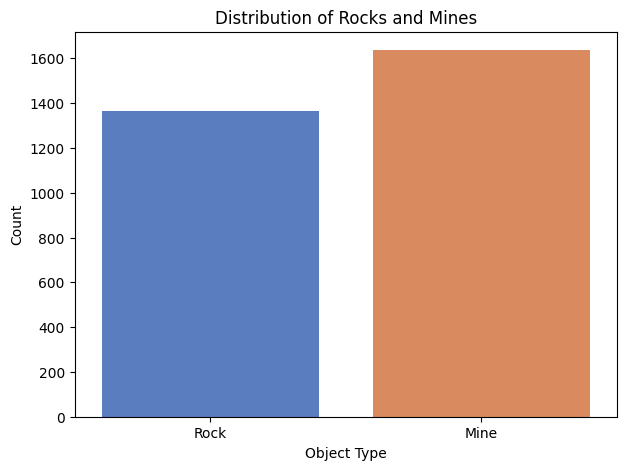

In [ ]:
# Target Distribution

plt.figure(figsize=(7,5))
sns.countplot(x = sonar_data['Target'], hue = sonar_data['Target'], palette= 'muted', legend = False)
plt.xlabel('Object Type')
plt.ylabel('Count')
plt.title('Distribution of Rocks and Mines')
plt.xticks([0,1],['Rock', 'Mine'])
plt.show()

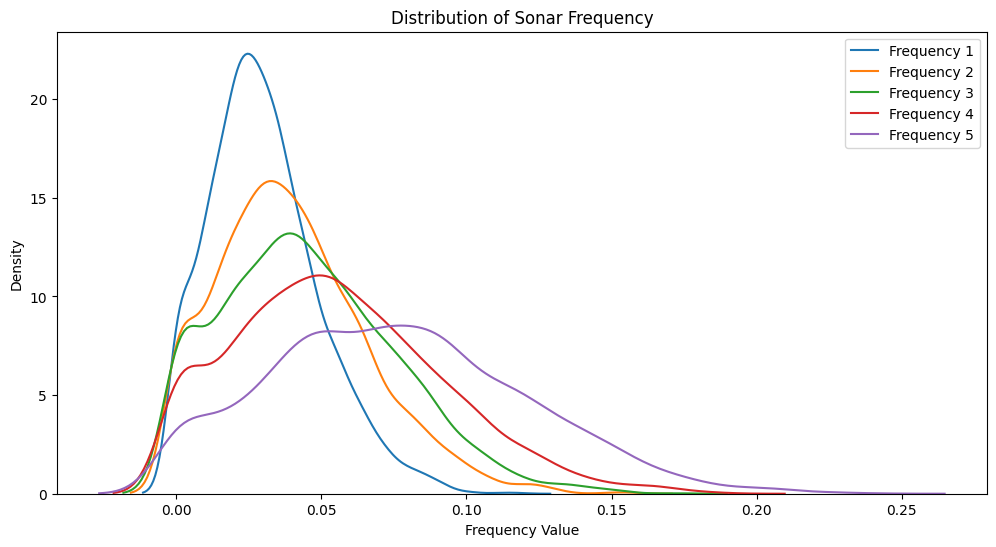

In [ ]:
# Feature Distribution (KDE Plot) for Skewness Analysis

# Since there are 60 features, plotting only the first few features

plt.figure(figsize=(12,6))
for i in range(1,6):
  frequency = f'Sonar_Frequency_{i:02d}'
  sns.kdeplot(
      data = sonar_data,
      x = frequency,
      label = f"Frequency {i}",
  )

plt.title('Distribution of Sonar Frequency')
plt.xlabel('Frequency Value')
plt.ylabel('Density')
plt.legend()

plt.show()

In [ ]:
# Skewness Analysis
# Positive values far from 0 are right skewed, 0 is considered as symmetric distribution

skewness = sonar_data.iloc[:,:-1].skew()

print('Top Positively Skewed Features:')
print(skewness.sort_values(ascending = False).head(10))

print('\nTop Negaively Skewed Features:')
print(skewness.sort_values().head(10))

Top Positively Skewed Features:
Sonar_Frequency_02    0.672723
Sonar_Frequency_01    0.670848
Sonar_Frequency_46    0.636614
Sonar_Frequency_45    0.629833
Sonar_Frequency_51    0.618831
Sonar_Frequency_52    0.571006
Sonar_Frequency_58    0.558931
Sonar_Frequency_03    0.553873
Sonar_Frequency_04    0.526056
Sonar_Frequency_59    0.512094
dtype: float64

Top Negaively Skewed Features:
Sonar_Frequency_27   -0.173548
Sonar_Frequency_25   -0.147131
Sonar_Frequency_26   -0.140409
Sonar_Frequency_29   -0.133522
Sonar_Frequency_28   -0.123676
Sonar_Frequency_24   -0.122473
Sonar_Frequency_23   -0.075214
Sonar_Frequency_22   -0.069483
Sonar_Frequency_30   -0.042708
Sonar_Frequency_21    0.005336
dtype: float64


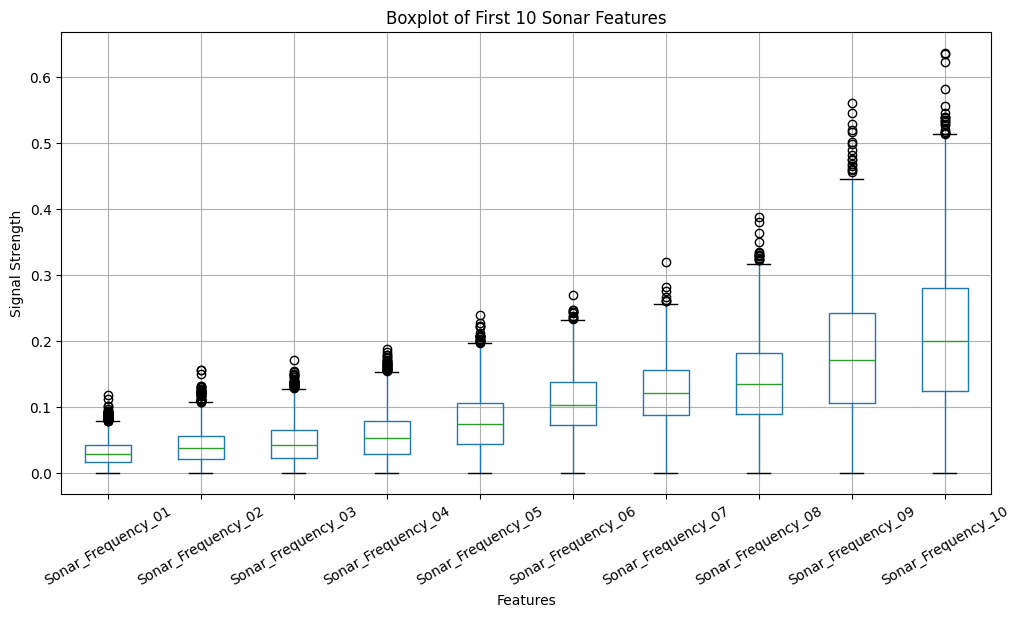

In [ ]:
# Feature Distribution (Box Plot) for Outlier Analysis

sonar_data.iloc[:,:10].boxplot(figsize=(12,6))
plt.title('Boxplot of First 10 Sonar Features')
plt.xlabel('Features')
plt.ylabel('Signal Strength')
plt.xticks(rotation = 30)

plt.show()

In [ ]:
# Outlier Analysis

Q1 = sonar_data.iloc[:,:-1].quantile(0.25)
Q3 = sonar_data.iloc[:,:-1].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((sonar_data.iloc[:,:-1] < lower_bound) | (sonar_data.iloc[:,:-1] > upper_bound))

outliers_count = outliers.sum()

print(f"Total Outliers: {outliers_count.sum()}")
print('\nFeatures with Potential Outliers:')
print(outliers_count[outliers_count>0].sort_values(ascending=False))
# Values which are 0 are not outliers.

Total Outliers: 945

Features with Potential Outliers:
Sonar_Frequency_01    50
Sonar_Frequency_59    46
Sonar_Frequency_45    42
Sonar_Frequency_54    41
Sonar_Frequency_46    40
Sonar_Frequency_02    39
Sonar_Frequency_60    35
Sonar_Frequency_03    31
Sonar_Frequency_44    31
Sonar_Frequency_51    31
Sonar_Frequency_58    30
Sonar_Frequency_04    30
Sonar_Frequency_52    27
Sonar_Frequency_47    26
Sonar_Frequency_55    23
Sonar_Frequency_05    21
Sonar_Frequency_10    20
Sonar_Frequency_53    19
Sonar_Frequency_48    18
Sonar_Frequency_09    16
Sonar_Frequency_11    15
Sonar_Frequency_08    15
Sonar_Frequency_17    14
Sonar_Frequency_43    13
Sonar_Frequency_16    12
Sonar_Frequency_28    12
Sonar_Frequency_39    12
Sonar_Frequency_50    11
Sonar_Frequency_49    11
Sonar_Frequency_33    11
Sonar_Frequency_57    11
Sonar_Frequency_34    10
Sonar_Frequency_40    10
Sonar_Frequency_37    10
Sonar_Frequency_06    10
Sonar_Frequency_15    10
Sonar_Frequency_29    10
Sonar_Frequency_36  

In [ ]:
# Manually Encoding Target Column

sonar_data['Target'] = sonar_data['Target'].replace({'R': 0, 'M': 1})
print(sonar_data['Target'].value_counts())

Target
1    1637
0    1363
Name: count, dtype: int64


/tmp/ipykernel_1845/207383729.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sonar_data['Target'] = sonar_data['Target'].replace({'R': 0, 'M': 1})


In [ ]:
# Split data into features (x) and target (y)
x = sonar_data.drop(columns='Target', axis = 1)
y = sonar_data['Target']

In [ ]:
# Handle missing values
imputer = SimpleImputer(strategy='median')
x_imputed = imputer.fit_transform(x)

# Validating Missing Values
print("Missing values before:", x.isnull().sum().sum())
print("Missing values after:", np.isnan(x_imputed).sum())

Missing values before: 486
Missing values after: 0


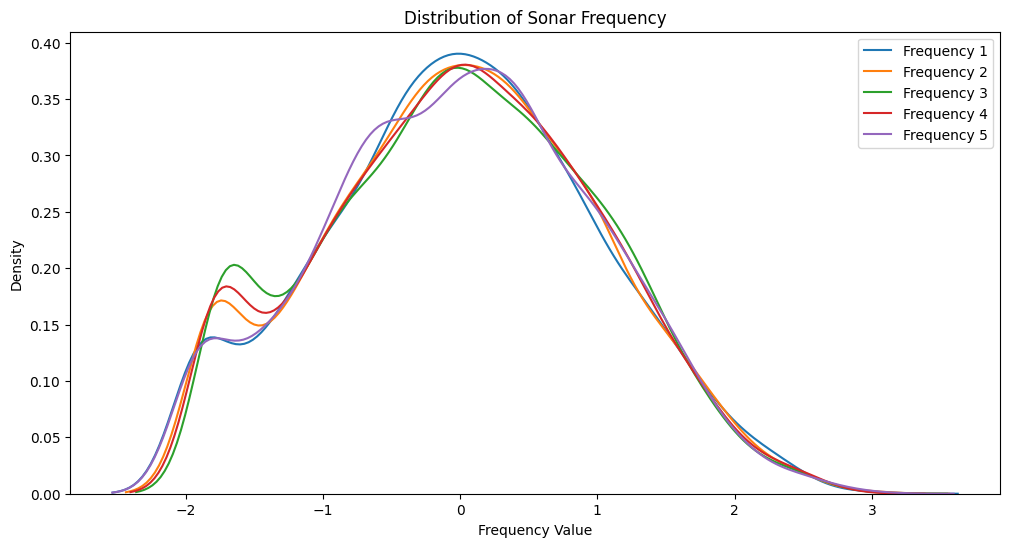

In [ ]:
# Handle skewness
power_transformer = PowerTransformer(method='yeo-johnson')
x_transformed = power_transformer.fit_transform(x_imputed)

data_transformed = pd.DataFrame(x_transformed, columns= x.columns)

# Validating Skewnes
plt.figure(figsize=(12,6))
for i in range(1,6):
  frequency = f'Sonar_Frequency_{i:02d}'
  sns.kdeplot(
      data = data_transformed,
      x = frequency,
      label = f"Frequency {i}",
  )

plt.title('Distribution of Sonar Frequency')
plt.xlabel('Frequency Value')
plt.ylabel('Density')
plt.legend()

plt.show()

In [ ]:
# Standardize features
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_transformed)

In [ ]:
# Split data into training and testing sets

x_train, x_test, y_train, y_test = train_test_split(x_scaled,y,test_size=0.20, random_state=42, stratify = y)
# stratify = y: for training and testing sets to preserve approximately the same class distribution

In [ ]:
# Applying PCA for dimensionality reduction

pca = PCA(n_components=0.95)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

print("Original number of features:", x_train.shape[1])
print("Reduced number of features:", x_train_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_.sum())

Original number of features: 60
Reduced number of features: 19
Explained variance: 0.9502114687609389


In [ ]:
# Creating PCA DataFrames

pca_columns = [
    f'PCA_{i:02d}'
    for i in range(1, x_train_pca.shape[1] + 1)
]

x_train_pca_df = pd.DataFrame(
    x_train_pca,
    columns=pca_columns,
    )

x_test_pca_df = pd.DataFrame(
    x_test_pca,
    columns=pca_columns,
)

print("Reduced training dataset:")
display(x_train_pca_df.head())

print("\nReduced testing dataset:")
display(x_test_pca_df.head())

Reduced training dataset:


,PCA_01,PCA_02,PCA_03,PCA_04,PCA_05,PCA_06,PCA_07,PCA_08,PCA_09,PCA_10,PCA_11,PCA_12,PCA_13,PCA_14,PCA_15,PCA_16,PCA_17,PCA_18,PCA_19
0,0.626884,-3.181943,-0.575517,-0.093516,-1.904009,1.096083,-0.958731,1.774317,0.630774,0.093806,0.352700,-0.440969,-1.748961,-0.087586,0.474974,0.097755,-1.618632,-0.230000,-0.396375
1,4.046123,-3.227063,0.810416,0.793674,4.374218,1.855263,-2.261740,-0.872891,0.012957,-1.475640,-1.463751,0.614734,-0.461519,0.198237,-0.957760,0.462912,0.955059,-1.518064,0.392681
2,3.122090,1.081017,-4.011999,2.600159,0.443101,-3.261939,1.218453,0.857971,1.481075,1.020445,-0.961869,1.280664,1.064207,2.085071,-0.774992,0.262524,0.872754,-1.069853,-0.427766
3,-1.221887,4.027122,-0.993582,5.001947,0.545835,2.924776,-2.291747,-0.203323,0.299252,-1.759794,-0.192641,1.888065,0.668494,1.515910,-0.601413,-0.577353,-0.612746,-1.292072,0.310515
4,6.782971,-3.480969,5.464884,-0.531362,-0.200765,3.455883,-0.146511,-0.696925,-0.730551,0.866785,0.322184,-1.088203,0.176052,-1.305744,1.732639,1.252256,1.113437,-1.074262,0.232141



Reduced testing dataset:


,PCA_01,PCA_02,PCA_03,PCA_04,PCA_05,PCA_06,PCA_07,PCA_08,PCA_09,PCA_10,PCA_11,PCA_12,PCA_13,PCA_14,PCA_15,PCA_16,PCA_17,PCA_18,PCA_19
0,4.403649,4.334334,0.386473,0.872657,-1.622803,-1.435155,3.265412,-0.933076,1.949117,1.796457,-0.899564,-1.144596,0.618082,0.834815,-0.421129,-0.717984,-0.957380,-0.193346,-0.015095
1,-0.370263,2.660141,-0.676238,0.608966,-0.102561,2.138217,2.608537,0.597606,-0.488992,-0.834805,0.583326,-1.439643,-0.502452,-0.900292,0.111222,1.095225,0.609152,0.247570,-0.184521
2,0.351671,1.617765,3.189005,1.248692,1.699070,0.946162,-0.537010,0.231031,0.510931,1.617257,0.661601,-1.880686,1.109004,-1.482885,1.062261,0.408735,-2.069791,-0.353512,-0.595958
3,5.280855,2.796044,0.385484,-1.446438,-1.774844,0.096462,1.726780,0.716917,1.175437,-0.426868,0.003117,-1.064114,-0.432412,0.832300,-0.305353,1.744699,0.325899,-0.203043,-2.056872
4,3.026523,5.662367,0.207034,-0.537440,3.427979,-1.201440,0.291428,-0.103591,-0.556094,-0.935837,1.530907,0.841488,0.089946,0.547660,-0.728343,0.193955,-1.261807,0.375516,0.286643


In [ ]:
# Create the Models

logistic_model = LogisticRegression(max_iter=2000)

svm_model = SVC(probability=True)

knn_model = KNeighborsClassifier()

rf_model = RandomForestClassifier(random_state=42)

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

In [ ]:
# Putting the Models in a Dictionary

models = {
    'Logistic Regression': logistic_model,
    'SVM': svm_model,
    'KNN': knn_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

In [ ]:
# Model Selection using Cross-Validation Technique

# Reason for using x_train and y_train instead of x and y:
# Taking only training data and spliting it into 5 parts. Training on 4 parts and validating on the remaining part

for name, model in models.items():

    scores = cross_val_score(
        model,
        x_train_pca_df,
        y_train,
        cv=5,
        scoring='f1'
    )

    print(f"{name}: {scores.mean() * 100:.2f}%")

Logistic Regression: 86.09%
SVM: 93.63%
KNN: 88.43%
Random Forest: 91.34%
XGBoost: 91.86%


In [ ]:
# Hyperparameter tuning

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto'],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

grid_search = GridSearchCV(
    estimator = svm_model,
    param_grid = param_grid,
    cv = 5,
    scoring = 'f1',
    n_jobs = -1
)

# Train the model
grid_search.fit(x_train_pca_df, y_train)

print(f'Best Parameter: {grid_search.best_params_}')
print(f'\nBest Cross-Validation F1 Score: {grid_search.best_score_ * 100:.2f}%')

Best Parameter: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Best Cross-Validation F1 Score: 93.87%


In [ ]:
# Best model

best_model = grid_search.best_estimator_
print(best_model)

SVC(C=10, probability=True)


In [ ]:
# Evaluation on Training Data first to understand how well the model has learned.

# Make Predictions on training data
train_data_prediction = best_model.predict(x_train_pca_df)

# Evaluate the model on training data
accuracy_train = accuracy_score(y_train, train_data_prediction)
precision_train = precision_score(y_train, train_data_prediction, average = 'binary')
recall_train = recall_score(y_train, train_data_prediction, average = 'binary')
f1_score_train = f1_score(y_train, train_data_prediction, average = 'binary')

print('------------- Performance on Training Data -------------\n')
print(f"Accuracy: {accuracy_train * 100:.2f}%")
print(f"Precision: {precision_train * 100:.2f}%")
print(f"Recall: {recall_train * 100:.2f}%")
print(f"F1 Score: {f1_score_train * 100:.2f}%")

------------- Performance on Training Data -------------

Accuracy: 99.29%
Precision: 99.54%
Recall: 99.16%
F1 Score: 99.35%


In [ ]:
# Making Predictions on testing data
test_data_prediction = best_model.predict(x_test_pca_df)

# Evaluating the model on testing data
accuracy_test = accuracy_score(y_test, test_data_prediction)
precision_test = precision_score(y_test, test_data_prediction, average = 'binary')
recall_test = recall_score(y_test, test_data_prediction, average = 'binary')
f1_score_test = f1_score(y_test, test_data_prediction, average = 'binary')

print('------------- Final Test Set Performance -------------\n')
print(f"Accuracy: {accuracy_test * 100:.2f}%")
print(f"Precision: {precision_test * 100:.2f}%")
print(f"Recall: {recall_test * 100:.2f}%")
print(f"F1 Score: {f1_score_test * 100:.2f}%")

------------- Final Test Set Performance -------------

Accuracy: 94.67%
Precision: 94.56%
Recall: 95.72%
F1 Score: 95.14%


In [ ]:
# Computing Confusion Matrix
cm = confusion_matrix(y_test, test_data_prediction)
print('Confusion Matrix:\n',cm)

# 18 Rocks incorrectly classified as Mine
# 14 Mines incorrectly classified as Rock

Confusion Matrix:
 [[255  18]
 [ 14 313]]


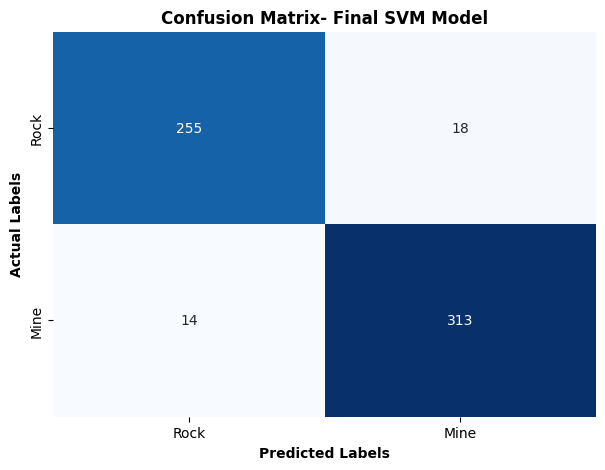

In [ ]:
# Plot Confusion Matrix
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot= True, fmt='d', cmap= 'Blues', cbar=False,
            xticklabels=['Rock', 'Mine'],
            yticklabels=['Rock', 'Mine'])

# Add labels to the plot
plt.xlabel('Predicted Labels', fontweight='bold')
plt.ylabel('Actual Labels', fontweight='bold')
plt.title('Confusion Matrix- Final SVM Model', fontweight = 'bold')
plt.show()

In [ ]:
# Classification Report
classification_report_test = classification_report(y_test, test_data_prediction, target_names = ['Rock', 'Mine'])
print(classification_report_test)

              precision    recall  f1-score   support

        Rock       0.95      0.93      0.94       273
        Mine       0.95      0.96      0.95       327

    accuracy                           0.95       600
   macro avg       0.95      0.95      0.95       600
weighted avg       0.95      0.95      0.95       600



In [ ]:
# ROC-AUC (Receiver Operating Characteristic – Area Under the Curve.)
# It is used mainly for binary classification

y_test_probability = best_model.predict_proba(x_test_pca_df)[:,1]

roc_auc = roc_auc_score(
    y_test,
    y_test_probability,
)

print(f'ROC-AUC Score: {roc_auc * 100:.2f}%')
# There is 99.03% chance of assigning a higher probability to the Mine sample than to the Rock sample, which is Excellent discrimination.

ROC-AUC Score: 99.03%


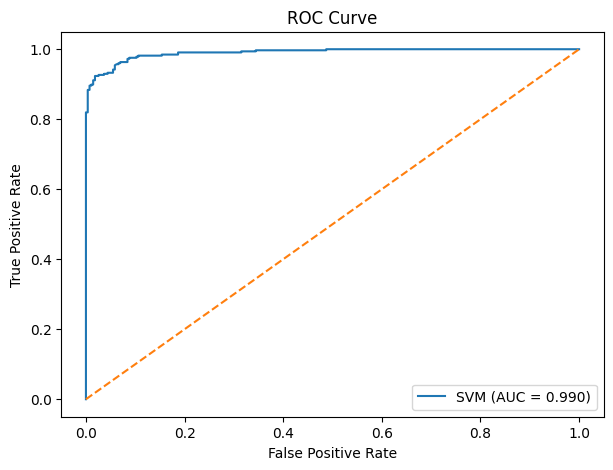

In [ ]:
# Plotting ROC-AUC Curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_test_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'SVM (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc = 'lower right')
plt.show()

In [ ]:
# New Sample Prediction

new_sample = pd.DataFrame([[
    0.0200, 0.0371, 0.0428, 0.0207, 0.1954,
    0.0986, 0.4539, 0.1601, 0.3109, 0.2131,
    0.1609, 0.1582, 0.2238, 0.0645, 0.0660,
    0.6167, 0.0180, 0.0084, 0.3090
]], columns = x_train_pca_df.columns)

# Making Predictions
new_pred = best_model.predict(new_sample)

if new_pred[0] == 0:
  print('Prediction: Rock')
else:
  print('Prediction: Mine')

# Prediction Probability
probability = best_model.predict_proba(new_sample)

print(f"Probability of Rock: {probability[0][0] * 100:.2f}%")
print(f"Probability of Mine: {probability[0][1] * 100:.2f}%")

Prediction: Rock
Probability of Rock: 97.45%
Probability of Mine: 2.55%


In [ ]:
import joblib

joblib.dump(best_model, 'sonar_final_model.pkl')

print("Model saved successfully!")

Model saved successfully!


In [ ]:
pip install streamlit joblib pandas numpy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 21.7 MB/s eta 0:00:00


In [ ]:
%%writefile app.py

Writing app.py


In [ ]:
%%writefile requirements.txt

Writing requirements.txt


In [ ]:
! wget -q -O - ipv4.icanhazip.com

34.125.134.242


In [ ]:
! streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴

⠦⠧⠇Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-09-23 06:36:44.298 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.125.134.242:8501

  Stopping...
^C
